# FitzHugh–Nagumo benchmark of Ramsay et al. (2007): forward problem with time-marching PINNs (PyTorch)

Model of Ramsay, Hooker, Campbell & Cao (2007), *Parameter estimation for differential equations:
a generalized smoothing approach*, JRSS-B 69(5), Section 3.1, in the paper's parameterisation:

$$
\frac{dV}{dt} = c\left(V - \frac{V^3}{3} + R\right), \qquad
\frac{dR}{dt} = -\frac{1}{c}\,\big(V - a + b\,R\big), \qquad
V(0) = -1,\; R(0) = 1,
$$

with $a = 0.2$, $b = 0.2$, $c = 3$ on $t \in [0, 20]$.

This is the **forward** problem only: the parameters are known and fixed, and the networks are trained
only on the ODE residual (no data, no parameter estimation). The RK45 solution is used purely for
validation.

Framework, network and training loop are the same as in `FitzHugh-Nagumo-PINN-torch.ipynb`:
$[0, 20]$ is split into windows $[t_k, t_{k+1}]$, each window has its own small MLP, and its initial
condition is the end state of window $k-1$. The solution has a period of $\approx 9$, with sharp
upstrokes of $V$ ($|dV/dt| \approx 5$) near $t \approx 0.6,\ 9.6,\ 18.6$, so the windows are short
(length 2).

## Parameters (edit here)

In [1]:
# ---------------- ODE parameters (Ramsay et al. 2007, Sec. 3.1) ----------------
a = 0.5 #0.2
b = 0.5 #0.2
c = 3.0

# ---------------- Initial conditions ----------------
V0 = -1.0
R0 = 1.0

# ---------------- Time interval ----------------
t0      = 0.0
t_final = 20.0
n_eval  = 4000     # output grid for plots / comparison

# ---------------- Time-marching PINN settings ----------------
window_length  = 2.0    # length of each time window
n_colloc       = 400    # collocation points per window (uniform grid)
hidden_layers  = 3
hidden_width   = 32
adam_epochs    = 500    # Adam warm-up per window
adam_lr        = 1.0e-3
lbfgs_max_iter = 3000   # L-BFGS refinement per window
seed           = 0
num_threads    = 16     # CPU threads for torch

## Imports and setup

In [2]:
import time
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"   # or "1" to use the second GPU

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.integrate import solve_ivp
from torch import nn

torch.manual_seed(seed)
np.random.seed(seed)
torch.set_num_threads(num_threads)

# float32 on GPU if available, otherwise CPU + float64 (same logic as the torch FHN notebook).
# In float32, L-BFGS typically stalls at residual losses ~1e-6.
if torch.cuda.is_available():
    device = torch.device("cuda")
    dtype = torch.float32
else:
    device = torch.device("cpu")
    dtype = torch.float64
print(f"torch {torch.__version__}, device {device}, dtype {dtype}")

torch 2.1.0, device cuda, dtype torch.float32


## Model

Inside window $[t_a, t_b]$, with $s = (t - t_a)/(t_b - t_a) \in [0, 1]$,

$$
\big(V, R\big)(t) = \big(V_a, R_a\big) + s\,\mathcal{N}_\theta(2s - 1),
$$

so the initial condition of each window (and continuity between windows) holds exactly.

The loss is the mean squared ODE residual on a uniform grid. In the paper's form the $V$-equation
is $O(c)$ and $dR/dt$ is $O(1/c)$, so the $V$-equation is divided by $c$ and the $R$-equation is
multiplied by $c$. Both residuals are then $O(1)$, and the ODE and its solution are unchanged:

$$
\mathcal{L} = \frac{1}{N}\sum_i \Big(\tfrac{1}{c}\dot V - V + \tfrac{V^3}{3} - R\Big)^2
+ \Big(c\,\dot R + V - a + b R\Big)^2 .
$$

In [3]:
class WindowPINN(nn.Module):
    # MLP on one time window with a hard-coded initial condition.

    def __init__(self, t_a, t_b, y_a, hidden_layers, hidden_width):
        super().__init__()
        self.t_a, self.t_b = t_a, t_b
        layers, width_in = [], 1
        for _ in range(hidden_layers):
            linear = nn.Linear(width_in, hidden_width)
            nn.init.xavier_normal_(linear.weight)
            nn.init.zeros_(linear.bias)
            layers += [linear, nn.Tanh()]
            width_in = hidden_width
        output = nn.Linear(width_in, 2)
        nn.init.xavier_normal_(output.weight)
        nn.init.zeros_(output.bias)
        layers.append(output)
        self.net = nn.Sequential(*layers)
        self.register_buffer("y_a", torch.as_tensor(y_a, dtype=dtype))

    def forward(self, t):
        s = (t - self.t_a) / (self.t_b - self.t_a)
        return self.y_a + s * self.net(2.0 * s - 1.0)


def ode_residual(model, t):
    t = t.detach().requires_grad_(True)
    y = model(t)
    V, R = y[:, 0:1], y[:, 1:2]
    dV = torch.autograd.grad(V, t, torch.ones_like(V), create_graph=True)[0]
    dR = torch.autograd.grad(R, t, torch.ones_like(R), create_graph=True)[0]
    r_V = dV / c - (V - V**3 / 3.0 + R)
    r_R = c * dR + (V - a + b * R)
    return r_V, r_R


def residual_loss(model, t):
    r_V, r_R = ode_residual(model, t)
    return (r_V**2 + r_R**2).mean()

## Train window by window (Adam warm-up, then L-BFGS)

In [4]:
def train_window(t_a, t_b, y_a):
    model = WindowPINN(t_a, t_b, y_a, hidden_layers, hidden_width).to(device, dtype)
    t_col = torch.linspace(t_a, t_b, n_colloc, dtype=dtype, device=device)[:, None]
    history = []

    adam = torch.optim.Adam(model.parameters(), lr=adam_lr)
    for _ in range(adam_epochs):
        adam.zero_grad()
        loss = residual_loss(model, t_col)
        loss.backward()
        adam.step()
        history.append(loss.item())

    lbfgs = torch.optim.LBFGS(
        model.parameters(),
        lr=1.0,
        max_iter=lbfgs_max_iter,
        history_size=100,
        tolerance_grad=1e-12,
        tolerance_change=1e-16,
        line_search_fn="strong_wolfe",
    )

    def closure():
        lbfgs.zero_grad()
        loss = residual_loss(model, t_col)
        loss.backward()
        history.append(loss.item())
        return loss

    lbfgs.step(closure)
    return model, history


edges = np.arange(t0, t_final + 1e-9, window_length)
if edges[-1] < t_final:
    edges = np.append(edges, t_final)

models, histories = [], []
y_a = [V0, R0]
start = time.time()
for t_a, t_b in zip(edges[:-1], edges[1:]):
    model, history = train_window(float(t_a), float(t_b), y_a)
    with torch.no_grad():
        y_a = model(torch.tensor([[t_b]], dtype=dtype, device=device))[0].tolist()
    models.append(model)
    histories.append(history)
    print(f"window [{t_a:5.1f}, {t_b:5.1f}]  final loss {history[-1]:.2e}  "
          f"({len(history)} evals, {time.time() - start:.0f}s)")

window [  0.0,   2.0]  final loss 3.40e-07  (937 evals, 5s)
window [  2.0,   4.0]  final loss 5.59e-08  (620 evals, 7s)
window [  4.0,   6.0]  final loss 8.75e-08  (598 evals, 9s)
window [  6.0,   8.0]  final loss 1.46e-06  (1234 evals, 17s)
window [  8.0,  10.0]  final loss 6.64e-07  (1119 evals, 23s)
window [ 10.0,  12.0]  final loss 5.20e-07  (1178 evals, 30s)
window [ 12.0,  14.0]  final loss 1.56e-06  (557 evals, 31s)
window [ 14.0,  16.0]  final loss 1.81e-08  (579 evals, 33s)
window [ 16.0,  18.0]  final loss 1.16e-06  (857 evals, 37s)
window [ 18.0,  20.0]  final loss 9.92e-07  (1122 evals, 43s)


## Evaluate the PINN and the RK45 reference on the output grid

In [5]:
def pinn_predict(t):
    # Evaluate the piecewise PINN at times t (1D array).
    t = np.asarray(t, dtype=np.float64)
    idx = np.clip(np.searchsorted(edges, t, side="right") - 1, 0, len(models) - 1)
    out = np.empty((t.size, 2))
    with torch.no_grad():
        for k, model in enumerate(models):
            mask = idx == k
            if mask.any():
                tk = torch.tensor(t[mask][:, None], dtype=dtype, device=device)
                out[mask] = model(tk).cpu().numpy()
    return out[:, 0], out[:, 1]


def fitzhugh_nagumo_ramsay(t, y, a, b, c):
    V, R = y
    dV = c * (V - V**3 / 3.0 + R)
    dR = -(V - a + b * R) / c
    return [dV, dR]


t = np.linspace(t0, t_final, n_eval)
V, R = pinn_predict(t)

# Tight tolerances so the reference error is negligible next to the PINN error.
sol = solve_ivp(fitzhugh_nagumo_ramsay, (t0, t_final), [V0, R0], method="RK45", t_eval=t,
                args=(a, b, c), rtol=1e-10, atol=1e-12)
V_ref, R_ref = sol.y

err_V, err_R = np.abs(V - V_ref), np.abs(R - R_ref)
rel_l2 = np.sqrt(np.sum((V - V_ref)**2 + (R - R_ref)**2) / np.sum(V_ref**2 + R_ref**2))
print(f"relative L2 error (V, R): {rel_l2:.3e}")
print(f"max |V - V_ref| = {err_V.max():.3e},  max |R - R_ref| = {err_R.max():.3e}")

relative L2 error (V, R): 2.848e-03
max |V - V_ref| = 1.860e-02,  max |R - R_ref| = 3.564e-03


## Time series: PINN vs RK45

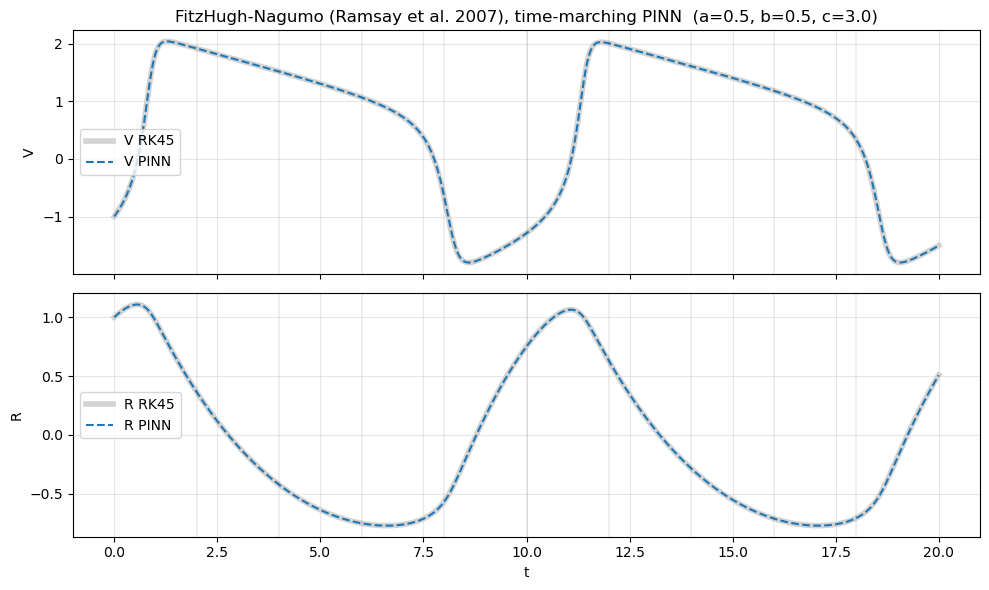

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for ax, pinn, ref, name in [(axes[0], V, V_ref, "V"), (axes[1], R, R_ref, "R")]:
    ax.plot(t, ref, color="lightgray", lw=4, label=f"{name} RK45")
    ax.plot(t, pinn, "--", lw=1.5, label=f"{name} PINN")
    for e in edges[1:-1]:
        ax.axvline(e, color="k", lw=0.3, alpha=0.3)
    ax.set_ylabel(name)
    ax.legend(loc="center left")
    ax.grid(alpha=0.3)
axes[1].set_xlabel("t")
axes[0].set_title(f"FitzHugh-Nagumo (Ramsay et al. 2007), time-marching PINN  (a={a}, b={b}, c={c})")
plt.tight_layout()
plt.show()

## Pointwise error

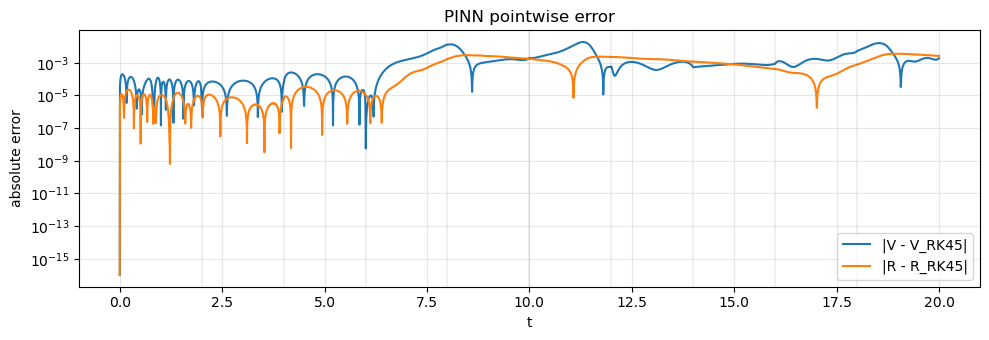

In [7]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.semilogy(t, err_V + 1e-16, label="|V - V_RK45|")
ax.semilogy(t, err_R + 1e-16, label="|R - R_RK45|")
for e in edges[1:-1]:
    ax.axvline(e, color="k", lw=0.3, alpha=0.3)
ax.set_xlabel("t")
ax.set_ylabel("absolute error")
ax.set_title("PINN pointwise error")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

## Phase plane

Nullclines: $R = V^3/3 - V$ ($\dot V = 0$) and $R = (a - V)/b$ ($\dot R = 0$).

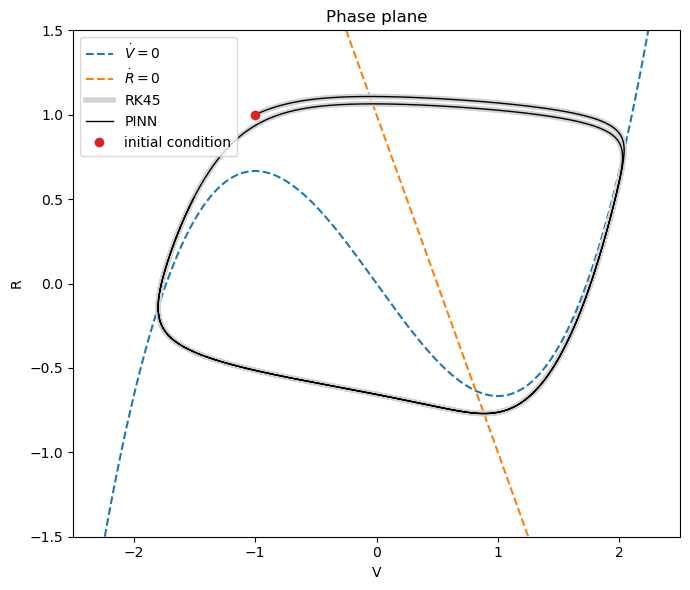

In [8]:
vv = np.linspace(-2.5, 2.5, 400)
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(vv, vv**3 / 3 - vv, "--", label=r"$\dot V = 0$")
ax.plot(vv, (a - vv) / b, "--", label=r"$\dot R = 0$")
ax.plot(V_ref, R_ref, color="lightgray", lw=4, label="RK45")
ax.plot(V, R, "k", lw=1.0, label="PINN")
ax.plot(V0, R0, "o", color="tab:red", label="initial condition")
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel("V")
ax.set_ylabel("R")
ax.set_title("Phase plane")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## Training history per window

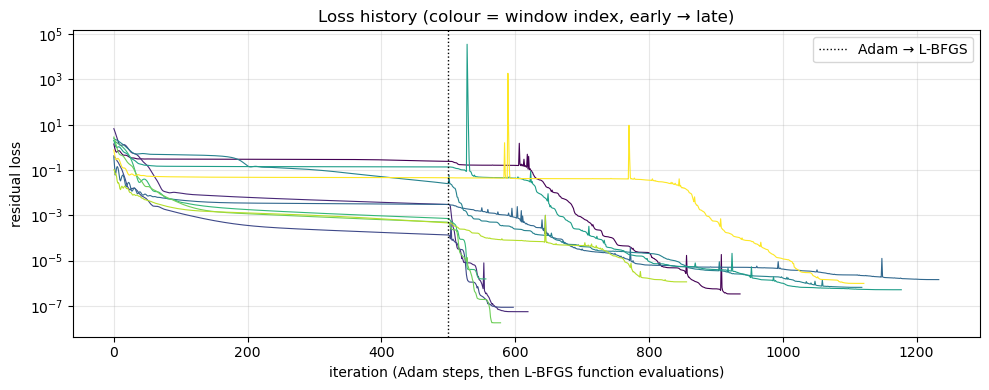

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
cmap = plt.get_cmap("viridis")
for k, history in enumerate(histories):
    ax.semilogy(history, color=cmap(k / max(len(histories) - 1, 1)), lw=0.8)
ax.axvline(adam_epochs, color="k", ls=":", lw=1, label="Adam → L-BFGS")
ax.set_xlabel("iteration (Adam steps, then L-BFGS function evaluations)")
ax.set_ylabel("residual loss")
ax.set_title("Loss history (colour = window index, early → late)")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()